In [3]:
import os
os.chdir("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipelines.catboost_pipe import CatBoostPipe

pipe = CatBoostPipe()

# All wheel force points plot

In [4]:
peaks = pipe.load("vertical_trials") # vertical_trials
peaks[:10]

[98.285400390625,
 88.50100708007812,
 68.07206726074219,
 48.18072509765625,
 110.06482696533203,
 112.22881317138672,
 71.83450317382812,
 53.38914108276367,
 106.1267318725586,
 105.71173095703125]

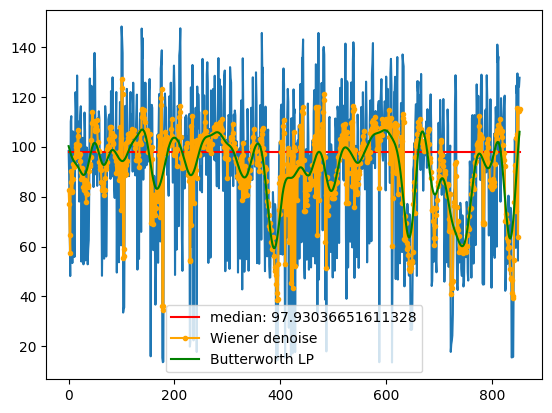

In [5]:
import scipy.signal


plt.plot(peaks)
plt.plot([np.median(peaks) for _ in range(len(peaks))],"-",c="r",label=f"median: {np.median(peaks)}")
# удалить белый шум: пример двух подходов

# 1) Адаптивный локальный фильтр (Wiener)
wiener_smoothed = scipy.signal.wiener(peaks, mysize=11)

# 2) Низкочастотный фильтр Баттерворта (устраняет высокочастотный шум)
b, a = scipy.signal.butter(3, 0.05)  # порядок 3, нормированная частота среза 0.05
butter_smoothed = scipy.signal.filtfilt(b, a, peaks)

plt.plot(wiener_smoothed, ".-", color="orange", label="Wiener denoise")
plt.plot(butter_smoothed, "-", color="green", label="Butterworth LP")
plt.legend()
plt.show()

# Raw forces peaks plot

In [4]:
import numpy as np
from pathlib import Path

file_path = "/home/daniil_gorenkov/dissertation/Dissertation/data/signals/straight/signal0555/А_2_2.dat"
mera_file = "/home/daniil_gorenkov/dissertation/Dissertation/data/signals/straight/signal0555/signal0555.mera"         # подставь имя
channel = os.path.basename(file_path).split(".")[0]

# Читаем мета-информацию (если нужно)
import configparser
config = configparser.ConfigParser(allow_no_value=True)
config.read(mera_file, encoding='windows-1251')
print(config.sections())


['MERA', 'A_1_1', 'А_1_2', 'А_1_3', 'А_1_4', 'А_2_1', 'А_2_2', 'А_2_3', 'А_2_4', 'Б_1_1', 'Б_1_2', 'Б_1_3', 'Б_1_4', 'Б_2_1', 'Б_2_2', 'Б_2_3', 'Б_2_4', 'В_1_1', 'В_1_2', 'В_1_3', 'В_1_4', 'В_2_1', 'В_2_2', 'В_2_3', 'В_2_4', 'Г_1_1', 'Г_1_2', 'Г_1_3', 'Г_1_4', 'Г_2_1', 'Г_2_2', 'Г_2_3', 'Г_2_4', 'Д_1_1', 'Д_1_2', 'Д_1_3', 'Д_1_4', 'Д_2_1', 'Д_2_2', 'Д_2_3', 'Д_2_4', 'Е_1_1', 'Е_1_2', 'Е_1_3', 'Е_1_4', 'Е_2_1', 'Е_2_2', 'Е_2_3', 'Е_2_4']


In [5]:

freq = float(config[channel]['freq'])
k1 = float(config[channel].get('k1', 1.0))
k0 = float(config[channel].get('k0', 0.0))
start = float(config[channel].get('start', 0.0))
units = config[channel]['yunits']

# Чтение данных
raw = np.fromfile(file_path, dtype=np.float32)

physical = raw * k1 + k0

time = np.arange(len(physical)) / freq + start

print(f"Канал {channel}: {len(physical):,} точек, ~{len(physical)/freq/60:.1f} минут")
print(f"Первые значения (физические, {units}):", physical[:8])
print(f"Мин / макс: {physical.min():.2f} … {physical.max():.2f} {units}")

Канал А_2_2: 28,800 точек, ~0.1 минут
Первые значения (физические, кН): [-0.01622095 -0.00043414 -0.09515502 -0.01622095 -0.06358139 -0.12672864
 -0.22144954 -0.15830228]
Мин / макс: -11.59 … 6.71 кН


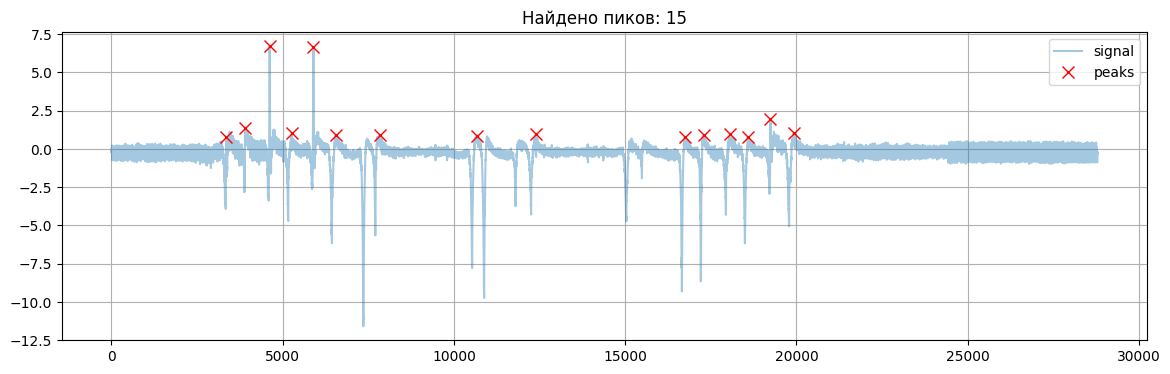

In [6]:
from scipy.signal import find_peaks

# signal_smooth = savgol_filter(signal, window_length=101, polyorder=3)

# ищем ОТРИЦАТЕЛЬНЫЕ пики
peaks, properties = find_peaks(
    physical,
    height=0.7,      # порог, подбери под свой шум
    distance=500      # минимальное расстояние между пиками
)

plt.figure(figsize=(14, 4))

plt.plot(physical, alpha=0.4, label="signal")
# plt.plot(signal_smooth, linewidth=2, label="smooth")

plt.plot(
    peaks,
    physical[peaks],
    "rx",
    markersize=8,
    label="peaks"
)

plt.legend()
plt.title(f"Найдено пиков: {len(peaks)}")
plt.grid(True)
plt.show()
